In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [79]:
data = pd.read_csv('medical_examination.csv')

## OVERWEIGHT

In [80]:
def is_overweight(row):
    
    w = row['weight']
    h = row['height']
    h = h/100
    
    bmi = (w/h**2)
    
    if h==0 or pd.isna(h) or pd.isna(w):
        return 0
        
    elif bmi>25 : 
        return 1 
    elif bmi <=25: 
        return 0

In [81]:
data['overweight'] = data.apply(is_overweight,axis=1)

In [82]:
data.head(5)

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


## NORMALIZE GLUCOSE & CHOLESTROL VALUES

In [83]:
def normalize_values(x):
    
    if x <=1:
        return 0
    
    elif x >1:
        return 1

In [84]:
data['gluc'] = data['gluc'].apply(normalize_values)
data['cholesterol'] = data['cholesterol'].apply(normalize_values)
data['age'] = data['age']/365

In [85]:
data.head(5)

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,50.391781,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,55.419178,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,51.663014,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,48.282192,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,47.873973,1,156,56.0,100,60,0,0,0,0,0,0,0


## Drawing Categorical Plot

In [86]:
# sns.countplot(x= 50.391781,data=['cholesterol', 'gluc', 'smoke', 'alco', 'active','overweight'],kind = 'box')
# plt.show()

In [96]:
#melt basically converts a wide frame into a longer frame
df_cat = data.melt(id_vars=["cardio"],value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active','overweight'],var_name='blood_parameters')
df_cat.head(5)

,cardio,blood_parameters,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0


In [100]:
## group and reformat 

#series
# df_cat.groupby(['cardio','blood_parameters','value']).size()


#dataframe
melted = df_cat.groupby(['cardio','blood_parameters','value']).size().reset_index(name='total')

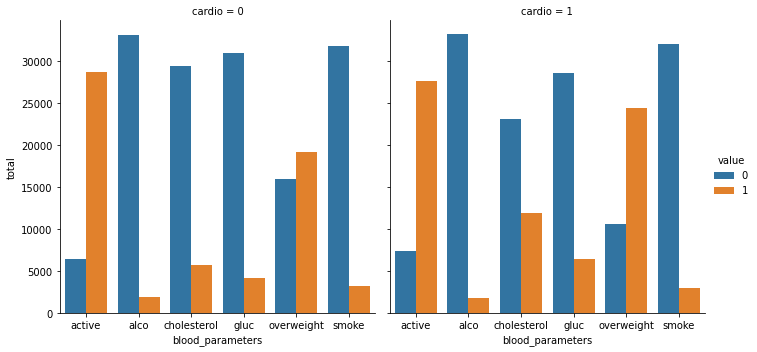

In [101]:
sns.catplot(data=melted,x="blood_parameters",y="total",hue="value",col="cardio",kind="bar")

In [102]:
#remove rows where diastolic pressure > systolic pressure, height/weight lies between 2.5th to 97.5 percentile

df_heat = data[(data['ap_lo']<=data['ap_hi'])&
(data['height']>=data['height'].quantile(0.025))&
(data['height']<=data['height'].quantile(0.975))&
(data['weight']>=data['weight'].quantile(0.025))&
(data['weight']<=data['weight'].quantile(0.975))]

df_heat


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,50.391781,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,55.419178,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,51.663014,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,48.282192,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,47.873973,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,53.969863,1,172,70.0,130,90,0,0,0,0,1,1,0
69994,99992,57.736986,1,165,80.0,150,80,0,0,0,0,1,1,1
69995,99993,52.712329,2,168,76.0,120,80,0,0,1,0,1,0,1
69998,99998,61.454795,1,163,72.0,135,80,0,1,0,0,0,1,1


In [108]:
#finding out corelation between
corelation = df_heat.corr()

<AxesSubplot:>

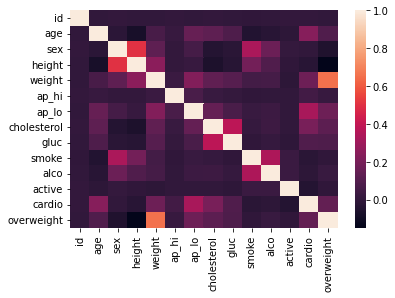

In [118]:
#
sns.heatmap(corelation)

<AxesSubplot:>

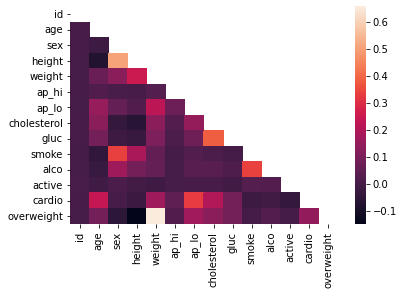

In [120]:
##keeping only upper triangle
mask = np.triu(np.ones_like(corelation,dtype=bool))
sns.heatmap(corelation,mask=mask)